# Batch Run Analysis

Load all `EpisodeRecord` pickles from a results folder and produce:

1. Distribution of cumulative profit across episodes
2. BET share per year (box plot across episodes)


In [15]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fleet_replacement.episode import EpisodeRecord

REPO_ROOT = pathlib.Path.cwd().parent

sns.set_theme(style="whitegrid")

In [16]:
import matplotlib

# PGF output settings — pdflatex + serif fonts matching a typical LaTeX article
matplotlib.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "pgf.rcfonts": False,  # use LaTeX's own font, not matplotlib's
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "font.size": 10,
        "axes.labelsize": 7,
        "axes.titlesize": 8,
        "legend.fontsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
    }
)

# Figures are saved here; create the directory if it doesn't exist
FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"PGF figures will be saved to: {FIGURES_DIR}")

PGF figures will be saved to: c:\git\KTH\fleet-replacement\figures


## Load batch results

Point `RESULTS_DIR` at the batch folder you want to analyse.  
All `episode_*.pkl` files in that folder are loaded automatically.


In [17]:
# ── Change this to the batch folder you want to analyse ──────────────────────
# RESULTS_DIR = REPO_ROOT / "results" / "important" / "batch_baseline_20260528_231106"
# RESULTS_DIR = REPO_ROOT / "results" / "important" / "batch_baseline_20260601_010719"
# RESULTS_DIR = REPO_ROOT / "results" / "important" / "batch_optimistic_20260529_005521"
RESULTS_DIR = REPO_ROOT / "results" / "batch_env_myopic_20260608_145548"
# ─────────────────────────────────────────────────────────────────────────────

pickle_files = sorted(RESULTS_DIR.glob("episode_*.pkl"))
records = [EpisodeRecord.load(str(f)) for f in pickle_files]

print(f"Loaded {len(records)} episodes from: {RESULTS_DIR.name}")
print(f"  Steps per episode : {records[0].n_steps}")
print(f"  Fleet size        : {records[0].fleet_size}")
print(f"  Years             : {records[0].years[0]} – {records[0].years[-1]}")

Loaded 200 episodes from: batch_env_myopic_20260608_145548
  Steps per episode : 20
  Fleet size        : 8
  Years             : 2026 – 2045


## Figure 1 — Distribution of cumulative profit across episodes


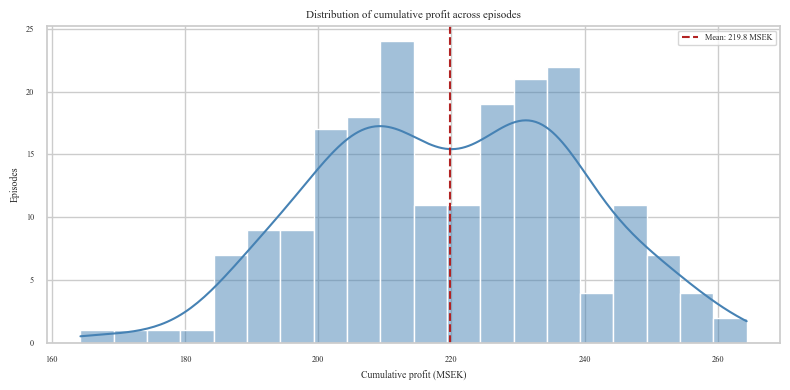

In [18]:
total_rewards = np.array([r.total_reward for r in records]) / 1e6  # MSEK

fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    total_rewards, binwidth=5, kde=True, ax=ax, color="steelblue", edgecolor="white"
)

ax.axvline(
    total_rewards.mean(),
    color="firebrick",
    linewidth=1.5,
    linestyle="--",
    label=f"Mean: {total_rewards.mean():.1f} MSEK",
)

ax.set_xlabel("Cumulative profit (MSEK)")
ax.set_ylabel("Episodes")
ax.set_title("Distribution of cumulative profit across episodes")
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig1_cumulative_profit.pgf", backend="pgf")
plt.show()

## Figure 2 — BET share per year (box plot across episodes)


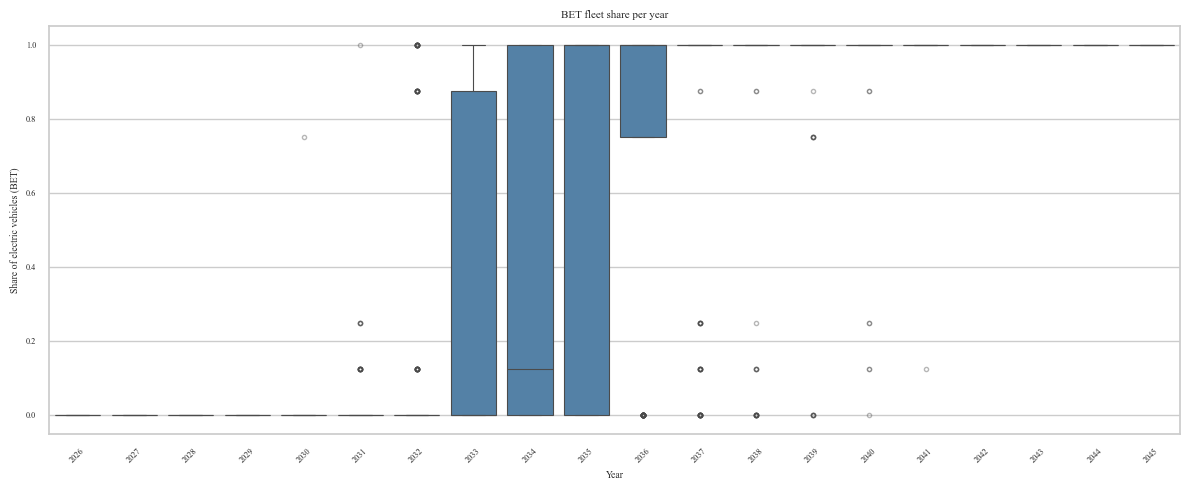

In [19]:
years = records[0].years

# Build long-form DataFrame: one row per (episode, year)
bet_share_long = pd.DataFrame(
    [
        {"year": year, "BET share": n_elec / r.fleet_size}
        for r in records
        for year, n_elec in zip(r.years, r.n_electric)
    ]
)

fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(
    data=bet_share_long,
    x="year",
    y="BET share",
    ax=ax,
    color="steelblue",
    linewidth=0.8,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
)

ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Year")
ax.set_ylabel("Share of electric vehicles (BET)")
ax.set_title("BET fleet share per year")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig2_bet_share.pgf", backend="pgf")
plt.show()

## Figure 3 — Explored uncertainty space

Each thin line is one episode's price trajectory. The shaded band spans the 25th–75th percentile across episodes and the solid line is the median. BET productivity is deterministic (logistic curve) so it is shown for reference only.


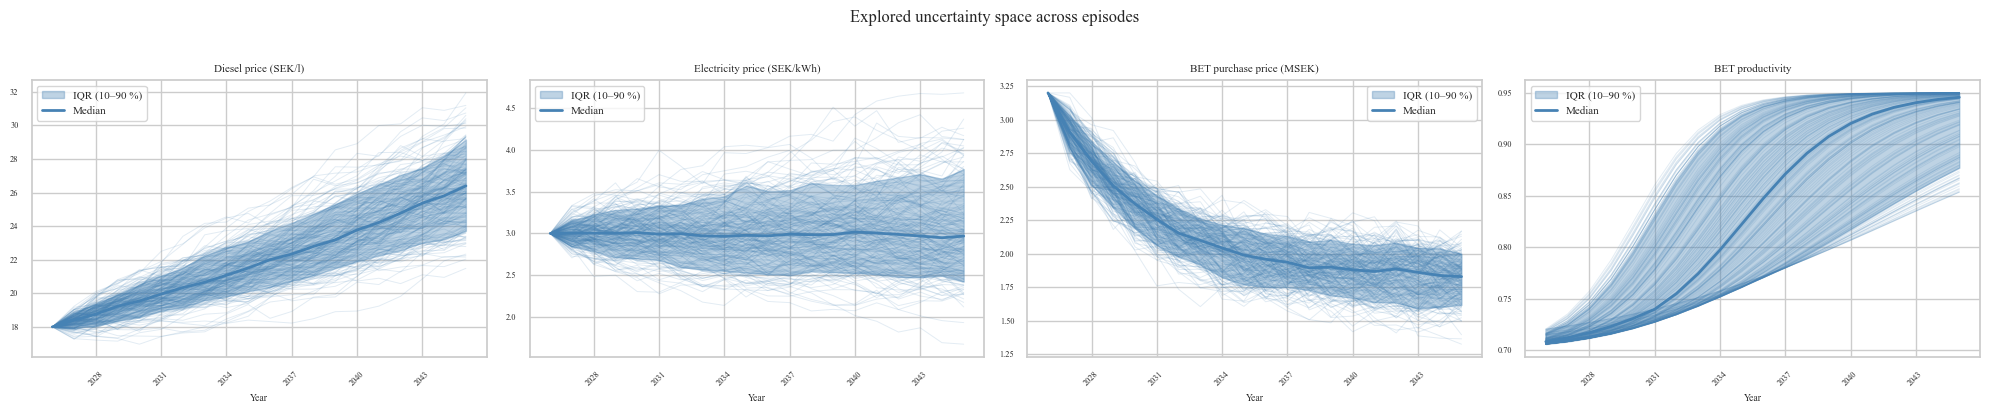

In [20]:
from matplotlib.ticker import MaxNLocator

_variables = {
    "Diesel price (SEK/l)": [r.energy_prices_diesel for r in records],
    "Electricity price (SEK/kWh)": [r.energy_prices_electricity for r in records],
    "BET purchase price (MSEK)": [r.purchase_prices_BET / 1e6 for r in records],
    "BET productivity": [r.productivities_BET for r in records],
}

years = records[0].years
n_cols = len(_variables)

fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=False)

for ax, (label, paths) in zip(axes, _variables.items()):
    mat = np.stack(paths)  # (n_episodes, n_steps)
    p10 = np.percentile(mat, 10, axis=0)
    p50 = np.percentile(mat, 50, axis=0)
    p90 = np.percentile(mat, 90, axis=0)

    # Individual episode trajectories
    for row in mat:
        ax.plot(years, row, color="steelblue", alpha=0.15, linewidth=0.7)

    # Median + IQR band
    ax.fill_between(
        years, p10, p90, color="steelblue", alpha=0.35, label="IQR (10–90 %)"
    )
    ax.plot(years, p50, color="steelblue", linewidth=2.0, label="Median")

    ax.set_title(label)
    ax.set_xlabel("Year")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

fig.suptitle("Explored uncertainty space across episodes", y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "fig3_uncertainty_space.pgf", backend="pgf")
plt.show()

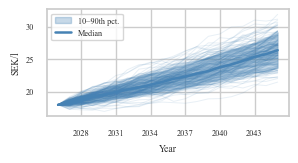

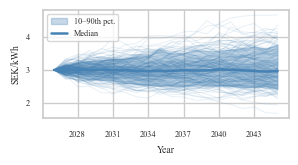

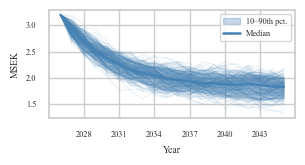

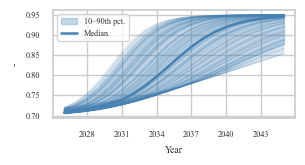

In [21]:
from matplotlib.ticker import MaxNLocator

# One figure per variable, sized for ~2x2 subfigures in a LaTeX document
# (textwidth = 468 pt => each panel is roughly half width)
panel_figsize = (3.15, 1.75)

uncertainty_panels = [
    (
        "SEK/l",
        [r.energy_prices_diesel for r in records],
        "uncertainty_diesel_price.pgf",
    ),
    (
        "SEK/kWh",
        [r.energy_prices_electricity for r in records],
        "uncertainty_electricity_price.pgf",
    ),
    (
        "MSEK",
        [r.purchase_prices_BET / 1e6 for r in records],
        "uncertainty_bet_purchase_price.pgf",
    ),
    (
        "-",
        [r.productivities_BET for r in records],
        "uncertainty_bet_productivity.pgf",
    ),
]

for ylabel, paths, filename in uncertainty_panels:
    mat = np.stack(paths)
    p10 = np.percentile(mat, 10, axis=0)
    p50 = np.percentile(mat, 50, axis=0)
    p90 = np.percentile(mat, 90, axis=0)

    fig, ax = plt.subplots(figsize=panel_figsize)

    for row in mat:
        ax.plot(years, row, color="steelblue", alpha=0.12, linewidth=0.7)

    ax.fill_between(
        years, p10, p90, color="steelblue", alpha=0.30, label="10–90th pct."
    )
    ax.plot(years, p50, color="steelblue", linewidth=1.8, label="Median")

    # ax.grid(False)
    ax.legend()
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / filename, backend="pgf", bbox_inches="tight")
    plt.show()